# **IDRA Capstone - Online Shopping Behaviour and Purchase Intent**

# 1. Project Overview

This project focuses on analysing online shopping behaviour and developing a machine learning model to predict whether a customer session will result in a purchase.

The analysis uses an e-commerce dataset containing customer, session, product, marketing, browsing and transaction-related information. The project aims to identify meaningful patterns in customer activity and determine which factors are associated with purchase behaviour.

The primary machine learning task is **classification**, where the target variable represents whether a purchase occurred during a shopping session.

### Project Workflow

The project will follow a structured data science workflow:

1. Dataset Understanding
2. Data Cleaning
3. Data Preprocessing
4. Exploratory Data Analysis
5. Statistical Analysis
6. Feature Engineering
7. Machine Learning Model Development
8. Model Evaluation
9. Results and Findings
10. Discussion
11. Limitations
12. Conclusion and Recommendations


### Target Variable

The target variable for the classification task is:

**purchased**

The target will be analysed separately from the predictor variables to avoid inappropriate use of the outcome during modelling.

### Objective of the Initial Dataset Audit

Before performing any cleaning or modelling, the raw dataset will be examined to understand:

- Dataset dimensions
- Available variables
- Data types
- Missing values
- Duplicate records
- Unique values and categories
- Numerical variable distributions
- Target variable distribution
- Potential data-quality issues
- Potential data leakage risks

This initial audit will provide the foundation for subsequent data cleaning, preprocessing, exploratory analysis and machine learning.

# 2. Dataset Understanding

## 2.1 Importing and Inspecting the Dataset

The first stage of the analysis is to inspect the raw dataset before applying any cleaning or preprocessing operations.

The purpose of this stage is to understand the structure, variables, data types and initial quality of the data. No observations will be removed or transformed at this stage.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Reproducibility
np.random.seed(42)

print("Libraries imported successfully.")

Libraries imported successfully.


<---------------------------------  Attention  --------------------------------->

## Follow this Step before moving next step.......
- You have given this below drive link of dataset.
- Go to that dataset,download it.
https://drive.google.com/file/d/1Ttl85dp8lugxXr79fZCYURsUX_eMPUDu/view?usp=sharing
- Upload to the next step...

<---------------------------------  Attention  --------------------------------->

In [5]:
from google.colab import files

uploaded = files.upload()

Saving P_10_Ecommerce.csv to P_10_Ecommerce.csv


In [6]:
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)
print("Dataset loaded successfully.")
print("File:", file_name)

Dataset loaded successfully.
File: P_10_Ecommerce.csv


## 2.2 Dataset Dimensions

The dimensions of the dataset are examined to determine the number of observations and variables available for analysis.

In [7]:
rows, columns = df.shape

print("Number of observations (rows):", rows)
print("Number of variables (columns):", columns)

Number of observations (rows): 25000
Number of variables (columns): 29


## 2.3 Initial Data Inspection

The first few observations are displayed to understand the structure and format of the variables before performing detailed data-quality checks.

In [8]:
df.head()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,discount_percent,discount_amount,revenue,pages_viewed,time_on_site_sec,added_to_cart,purchased,cart_abandoned,rating,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,20,130.31,0.00,21,965,1,0,1,4,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,15,567.16,0.00,21,1158,0,0,0,4,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,0,0.00,0.00,19,710,1,0,1,4,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,5,126.85,2410.23,19,1674,1,1,0,4,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,0,0.00,0.00,13,427,1,0,1,4,1,0,1,25,2,6,3,Very Short,0.000000,118


## 2.4 Complete Dataset Audit

A complete initial audit is performed to understand the structure and quality of the raw e-commerce dataset.

The audit examines:

- Dataset dimensions
- Column names
- Data types
- Missing values
- Duplicate records
- Number of unique values
- Numerical and categorical variables
- Basic descriptive statistics

At this stage, the original dataset is not modified. The results of this audit will be used to determine the appropriate data-cleaning and preprocessing strategy.

In [9]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows       : {df.shape[0]:,}")
print(f"Columns    : {df.shape[1]}")
print(f"Total Cells: {df.size:,}")

DATASET OVERVIEW
Rows       : 25,000
Columns    : 29
Total Cells: 725,000


In [10]:
print("=" * 60)
print("COLUMN INFORMATION")
print("=" * 60)

column_info = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str),
    "Non-Null": df.notna().sum(),
    "Missing": df.isna().sum(),
    "Unique": df.nunique()
})

display(column_info)

COLUMN INFORMATION


,Column,Data Type,Non-Null,Missing,Unique
customer_id,customer_id,int64,25000,0,8442
session_id,session_id,int64,25000,0,25000
visit_date,visit_date,object,25000,0,365
device_type,device_type,int64,25000,0,3
user_type,user_type,int64,25000,0,2
marketing_channel,marketing_channel,int64,25000,0,6
product_id,product_id,int64,25000,0,899
product_category,product_category,int64,25000,0,8
unit_price,unit_price,float64,25000,0,23136
quantity,quantity,int64,25000,0,4


## Missing Values

In [11]:
print("=" * 60)
print("MISSING VALUE SUMMARY")
print("=" * 60)

missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing %": (df.isna().mean() * 100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Count", ascending=False)

if missing_summary.empty:
    print("No missing values found.")
else:
    display(missing_summary)

MISSING VALUE SUMMARY
No missing values found.


## Duplicate Values

In [12]:
print("=" * 60)
print("DUPLICATE RECORDS")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].head(10))

DUPLICATE RECORDS
Duplicate rows: 0


## Numerical and Categorical Variables

In [13]:
print("=" * 60)
print("VARIABLE TYPES")
print("=" * 60)

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print(f"Numerical variables   : {len(numerical_columns)}")
print(f"Categorical variables : {len(categorical_columns)}")

print("\nNumerical:")
print(numerical_columns)

print("\nCategorical:")
print(categorical_columns)

VARIABLE TYPES
Numerical variables   : 27
Categorical variables : 2

Numerical:
['customer_id', 'session_id', 'device_type', 'user_type', 'marketing_channel', 'product_id', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'revenue', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased', 'cart_abandoned', 'rating', 'review_text', 'review_helpful_votes', 'payment_method', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'revenue_normalized', 'location']

Categorical:
['visit_date', 'session_duration_bucket']


## Unique Values of Categorical Variables

In [14]:
print("=" * 60)
print("CATEGORICAL VARIABLE VALUES")
print("=" * 60)

for col in categorical_columns:
    print(f"\n{col} ({df[col].nunique()} unique values)")
    print(df[col].unique()[:20])

CATEGORICAL VARIABLE VALUES

visit_date (365 unique values)
['28-11-2024' '25-09-2024' '31-05-2024' '30-01-2024' '25-02-2024'
 '29-03-2024' '28-05-2024' '19-11-2024' '13-02-2024' '29-07-2024'
 '06-05-2024' '18-01-2024' '14-08-2024' '14-09-2024' '16-12-2024'
 '03-07-2024' '28-04-2024' '07-11-2024' '31-03-2024' '06-09-2024']

session_duration_bucket (4 unique values)
['Long' 'Short' 'Very Long' 'Very Short']


## Numerical Descriptive Statistics


In [15]:
print("=" * 60)
print("NUMERICAL DESCRIPTIVE STATISTICS")
print("=" * 60)

numeric_summary = df[numerical_columns].describe().T
numeric_summary["median"] = df[numerical_columns].median()
display(numeric_summary)

NUMERICAL DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max,median
customer_id,25000.0,5479.930600,2593.544596,1000.00,3234.0000,5482.000,7715.0000,9998.00,5482.000
session_id,25000.0,12499.500000,7217.022701,0.00,6249.7500,12499.500,18749.2500,24999.00,12499.500
device_type,25000.0,0.705040,0.639543,0.00,0.0000,1.000,1.0000,2.00,1.000
user_type,25000.0,0.551280,0.497373,0.00,0.0000,1.000,1.0000,1.00,1.000
marketing_channel,25000.0,2.514040,1.704934,0.00,1.0000,2.000,4.0000,5.00,2.000
product_id,25000.0,449.107000,259.513787,0.00,225.0000,448.000,675.0000,898.00,448.000
product_category,25000.0,3.495240,2.285053,0.00,2.0000,4.000,5.0000,7.00,4.000
unit_price,25000.0,782.319010,476.612168,50.05,395.2225,691.725,1096.8425,1999.83,691.725
quantity,25000.0,2.489040,1.114563,1.00,1.0000,2.000,3.0000,4.00,2.000
discount_percent,25000.0,8.998800,9.263640,0.00,0.0000,10.000,15.0000,30.00,10.000


## 2.5 Target Variable Analysis

The target variable represents the outcome that the machine learning model will predict. In this project, the target variable is *purchased*, which indicates whether a customer session resulted in a purchase.

The distribution of the target classes is examined to understand the balance of the classification problem before model development.

In [16]:
target_column = "purchased"

print("=" * 60)
print("TARGET VARIABLE")
print("=" * 60)

print(f"Target: {target_column}")
print(f"Data Type: {df[target_column].dtype}")

print("\nUnique Values:")
print(df[target_column].unique())

target_counts = df[target_column].value_counts(dropna=False)
target_percent = df[target_column].value_counts(
    normalize=True, dropna=False
).mul(100).round(2)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percent
})

display(target_summary)

TARGET VARIABLE
Target: purchased
Data Type: int64

Unique Values:
[0 1]


,Count,Percentage
purchased,,
0,19384,77.54
1,5616,22.46


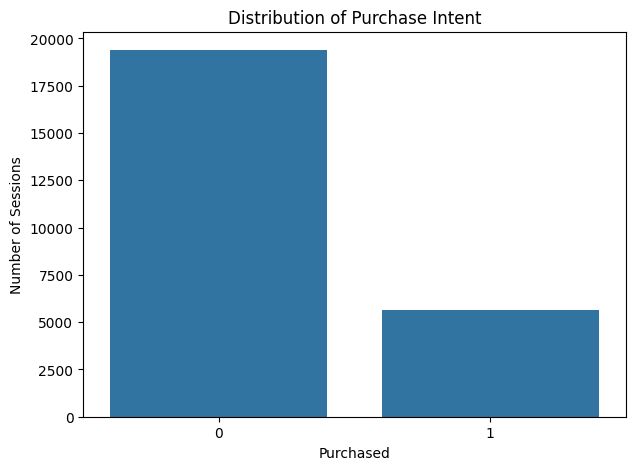

In [17]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x=target_column)

plt.title("Distribution of Purchase Intent")
plt.xlabel("Purchased")
plt.ylabel("Number of Sessions")

plt.show()

## 2.6 Audit Findings Summary

The initial dataset audit provides an overview of the dataset structure, data quality, variable types, and target distribution.

In [18]:
# Store the Audit result....
audit_summary = {
    "Rows": df.shape[0],
    "Columns": df.shape[1],
    "Missing Values": df.isna().sum().sum(),
    "Duplicate Rows": df.duplicated().sum(),
    "Numerical Variables": len(numerical_columns),
    "Categorical Variables": len(categorical_columns)
}

audit_summary

{'Rows': 25000,
 'Columns': 29,
 'Missing Values': np.int64(0),
 'Duplicate Rows': np.int64(0),
 'Numerical Variables': 27,
 'Categorical Variables': 2}

In [19]:
audit_table = pd.DataFrame(
    audit_summary.items(),
    columns=["Audit Metric", "Value"]
)

display(audit_table)

,Audit Metric,Value
0,Rows,25000
1,Columns,29
2,Missing Values,0
3,Duplicate Rows,0
4,Numerical Variables,27
5,Categorical Variables,2


In [20]:
print("Target Variable:", target_column)
print("Target Classes:", df[target_column].nunique())

display(target_summary)

Target Variable: purchased
Target Classes: 2


,Count,Percentage
purchased,,
0,19384,77.54
1,5616,22.46


# 3. Data Cleaning
The data-cleaning phase applies the necessary corrections identified during the dataset audit.

In [21]:
df_clean = df.copy()

print("Raw dataset shape    :", df.shape)
print("Working dataset shape:", df_clean.shape)

Raw dataset shape    : (25000, 29)
Working dataset shape: (25000, 29)


## remove the duplicatw  

In [22]:
duplicate_count = df_clean.duplicated().sum()

if duplicate_count > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print("Duplicates removed:", duplicate_count)
print("Current rows:", len(df_clean))

Duplicates removed: 0
Current rows: 25000


## Handle Missing Values

In [23]:
missing_before = df_clean.isna().sum().sum()

print("Missing values found:", missing_before)

if missing_before == 0:
    print("No missing-value treatment required.")

Missing values found: 0
No missing-value treatment required.


## Validate Cleaning

In [24]:
print("Cleaned dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isna().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())

Cleaned dataset shape: (25000, 29)
Missing values: 0
Duplicate rows: 0


## Save this cleaned File...

In [25]:
cleaned_file = "P_10_Ecommerce_Cleaned.csv"

df_clean.to_csv(cleaned_file, index=False)

print("Cleaned dataset saved successfully.")
print("File:", cleaned_file)

Cleaned dataset saved successfully.
File: P_10_Ecommerce_Cleaned.csv


In [26]:
import os

print("File exists:", os.path.exists(cleaned_file))
print("File size:", f"{os.path.getsize(cleaned_file) / 1024:.2f} KB")

File exists: True
File size: 2514.02 KB


# 4. Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand patterns, distributions, relationships, and trends within the cleaned e-commerce dataset.


## 4.1 Univariate Analysis

Univariate analysis examines individual variables to understand their distributions and general characteristics.

Numerical variables are analysed using descriptive statistics and visualizations such as histograms and box plots.

In [27]:
numeric_eda = df_clean.select_dtypes(include=np.number)

numeric_eda.describe().T

,count,mean,std,min,25%,50%,75%,max
customer_id,25000.0,5479.930600,2593.544596,1000.00,3234.0000,5482.000,7715.0000,9998.00
session_id,25000.0,12499.500000,7217.022701,0.00,6249.7500,12499.500,18749.2500,24999.00
device_type,25000.0,0.705040,0.639543,0.00,0.0000,1.000,1.0000,2.00
user_type,25000.0,0.551280,0.497373,0.00,0.0000,1.000,1.0000,1.00
marketing_channel,25000.0,2.514040,1.704934,0.00,1.0000,2.000,4.0000,5.00
product_id,25000.0,449.107000,259.513787,0.00,225.0000,448.000,675.0000,898.00
product_category,25000.0,3.495240,2.285053,0.00,2.0000,4.000,5.0000,7.00
unit_price,25000.0,782.319010,476.612168,50.05,395.2225,691.725,1096.8425,1999.83
quantity,25000.0,2.489040,1.114563,1.00,1.0000,2.000,3.0000,4.00
discount_percent,25000.0,8.998800,9.263640,0.00,0.0000,10.000,15.0000,30.00


In [28]:
eda_numeric_columns = [
    "unit_price",
    "quantity",
    "pages_viewed",
    "time_on_site_sec",
    "rating"
]

display(df_clean[eda_numeric_columns].describe().T)

,count,mean,std,min,25%,50%,75%,max
unit_price,25000.0,782.31901,476.612168,50.05,395.2225,691.725,1096.8425,1999.83
quantity,25000.0,2.48904,1.114563,1.00,1.0000,2.000,3.0000,4.00
pages_viewed,25000.0,12.53584,6.929762,1.00,7.0000,13.000,19.0000,24.00
time_on_site_sec,25000.0,903.26292,518.676202,10.00,453.0000,903.000,1355.0000,1799.00
rating,25000.0,3.94800,0.540470,1.00,4.0000,4.000,4.0000,5.00


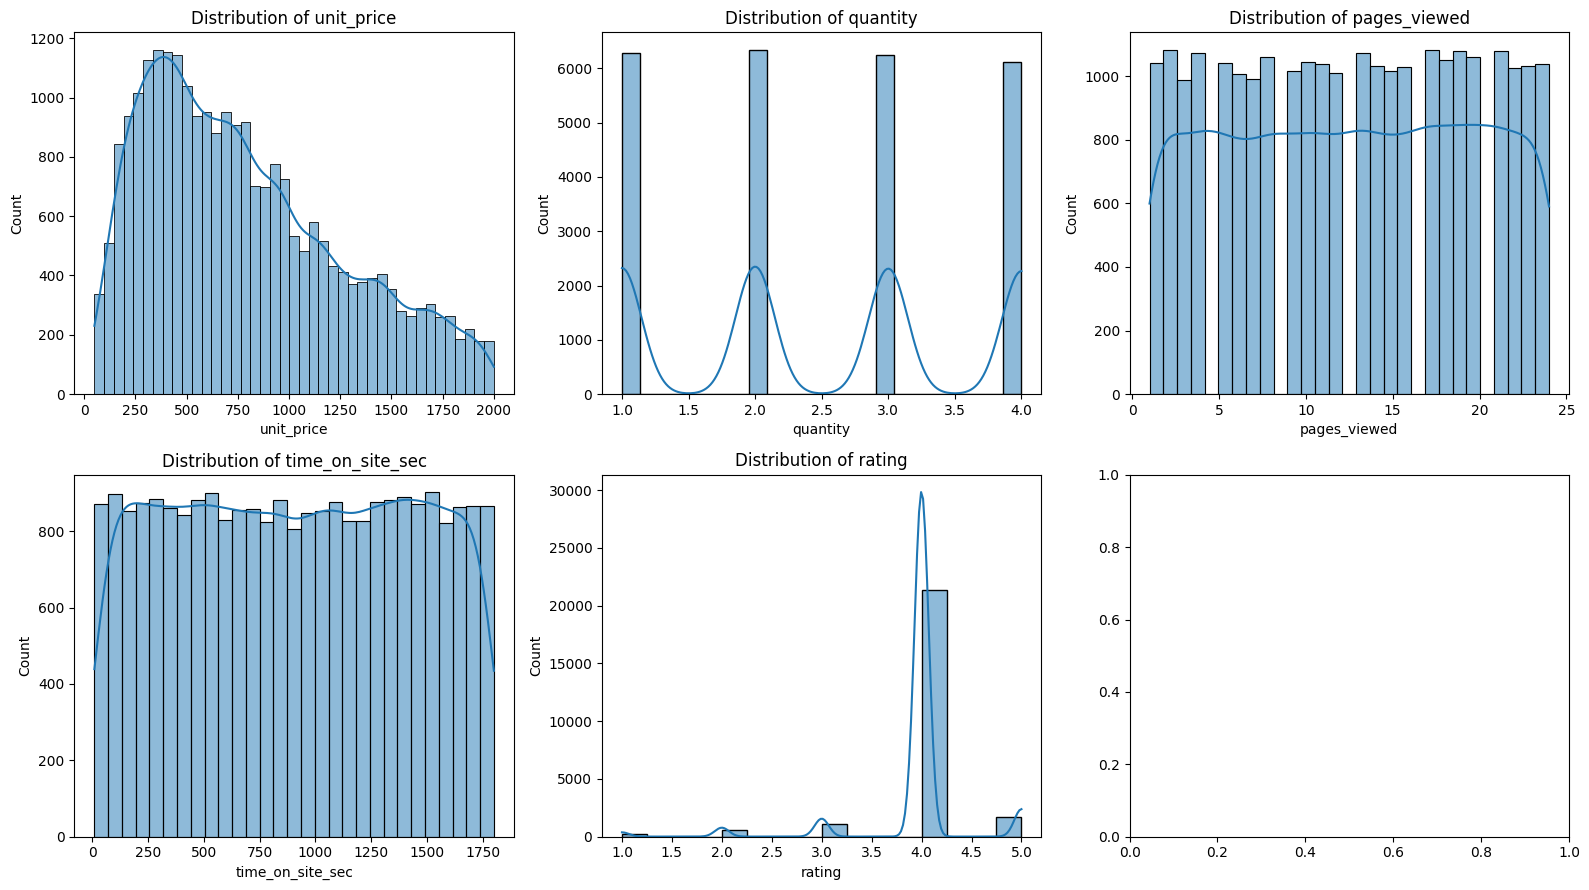

In [29]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, eda_numeric_columns):
    sns.histplot(df_clean[col], kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

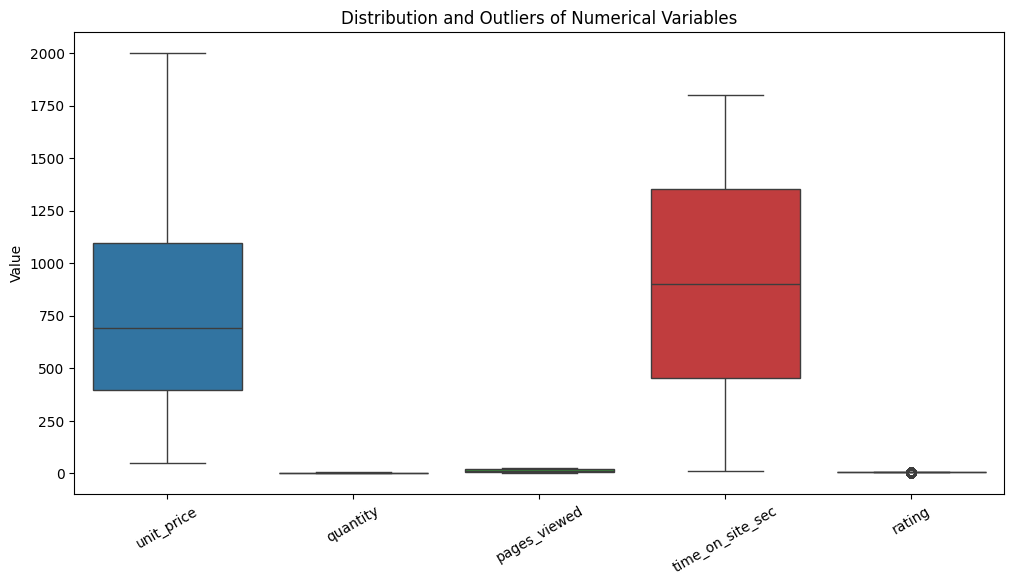

In [30]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_clean[eda_numeric_columns])

plt.title("Distribution and Outliers of Numerical Variables")
plt.xticks(rotation=30)
plt.ylabel("Value")
plt.show()

## 4.2 Categorical Analysis

Categorical variables are examined to understand the composition of the customer sessions.

## Select Variable

In [31]:
categorical_eda_columns = [
    "device_type",
    "user_type",
    "marketing_channel",
    "product_category",
    "payment_method",
    "visit_season"
]

print("Categorical variables selected:", len(categorical_eda_columns))
print(categorical_eda_columns)

Categorical variables selected: 6
['device_type', 'user_type', 'marketing_channel', 'product_category', 'payment_method', 'visit_season']


In [32]:
for col in categorical_eda_columns:
    print(f"\n{col}")
    display(df_clean[col].value_counts().to_frame("Count"))


device_type


,Count
device_type,
1,12600
0,9887
2,2513



user_type


,Count
user_type,
1,13782
0,11218



marketing_channel


...

,Count
product_category,
2,3237
4,3204
5,3149
0,3142
6,3112
7,3073
1,3043
3,3040



payment_method


,Count
payment_method,
1,4281
4,4229
0,4227
3,4140
5,4072
2,4051



visit_season


,Count
visit_season,
3,6275
2,6269
1,6247
0,6209


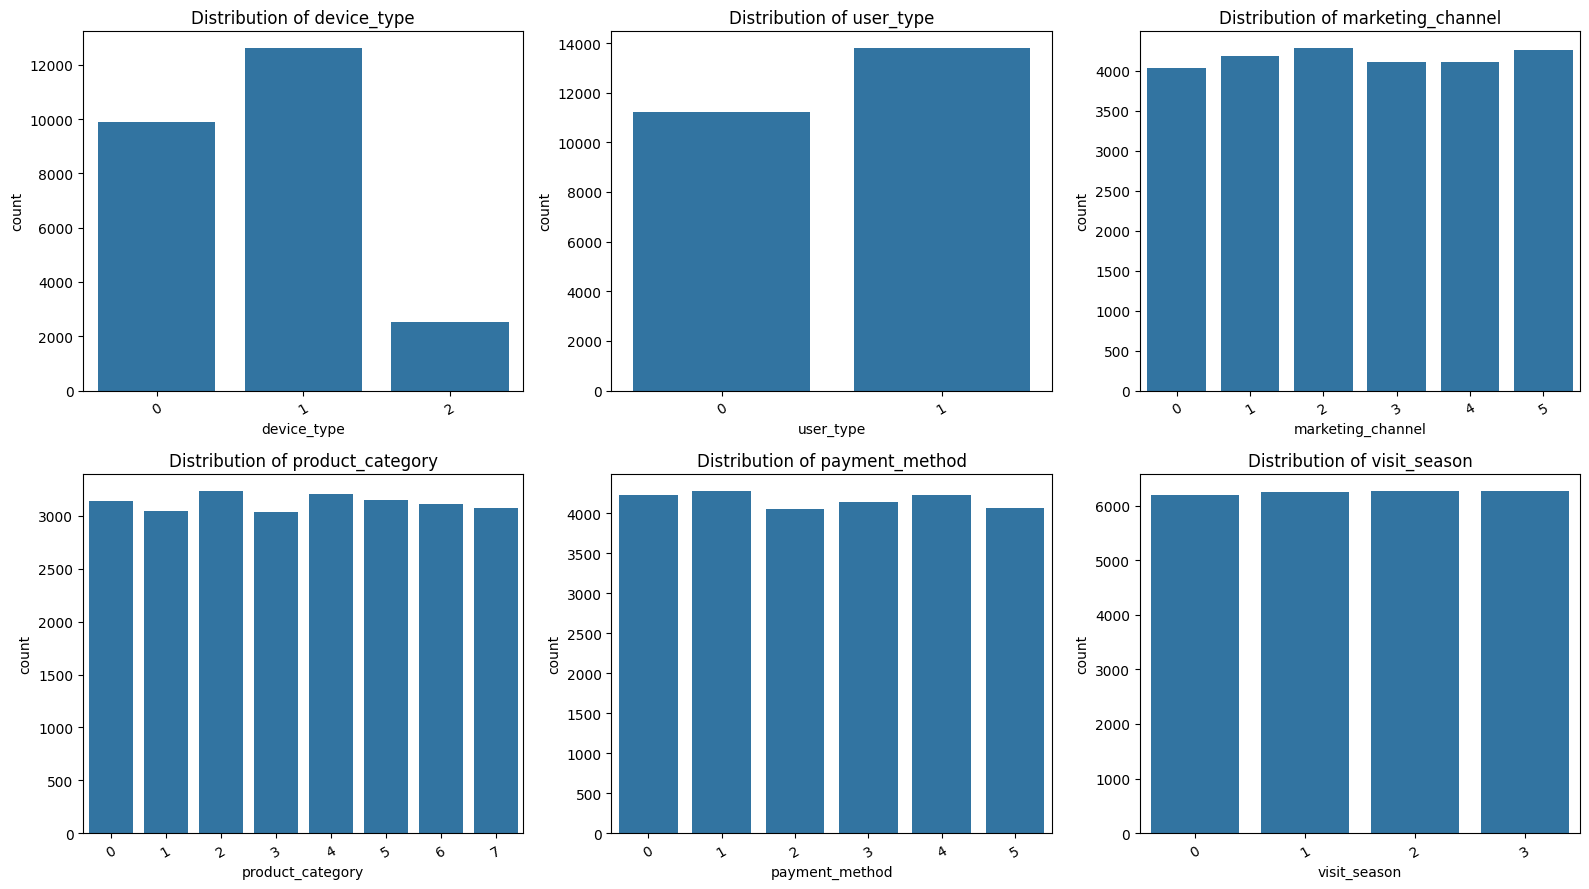

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flat, categorical_eda_columns):
    sns.countplot(data=df_clean, x=col, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

In [34]:
category_target = {}

for col in categorical_eda_columns:
    category_target[col] = (
        df_clean.groupby(col)["purchased"]
        .mean()
        .sort_values(ascending=False)
    )

category_target

{'device_type': device_type
 2    0.231994
 0    0.224638
 1    0.223175
 Name: purchased, dtype: float64,
 'user_type': user_type
 1    0.256494
 0    0.185505
 Name: purchased, dtype: float64,
 'marketing_channel': marketing_channel
 5    0.235984
 0    0.227171
 3    0.226433
 1    0.221241
 2    0.220276
 4    0.216598
 Name: purchased, dtype: float64,
 'product_category': product_category
 6    0.246787
 5    0.231185
 4    0.226904
 7    0.225838
 0    0.222788
 2    0.222737
 1    0.212619
 3    0.207566
 Name: purchased, dtype: float64,
 'payment_method': payment_method
 2    0.232041
 3    0.229227
 1    0.228918
 5    0.224214
 4    0.222038
 0    0.211734
 Name: purchased, dtype: float64,
 'visit_season': visit_season
 3    0.229960
 2    0.227628
 1    0.221546
 0    0.219359
 Name: purchased, dtype: float64}

## 4.3 Bivariate Analysis

Bivariate analysis examines the relationship between two variables.

In this project, behavioural and session-related variables are compared with the `purchased` target to identify differences between purchasing and non-purchasing sessions.

In [35]:
behavior_columns = [
    "pages_viewed",
    "time_on_site_sec"
]

behavior_summary = df_clean.groupby("purchased")[behavior_columns].mean()

display(behavior_summary)

,pages_viewed,time_on_site_sec
purchased,,
0,12.512846,895.605809
1,12.615207,929.691952


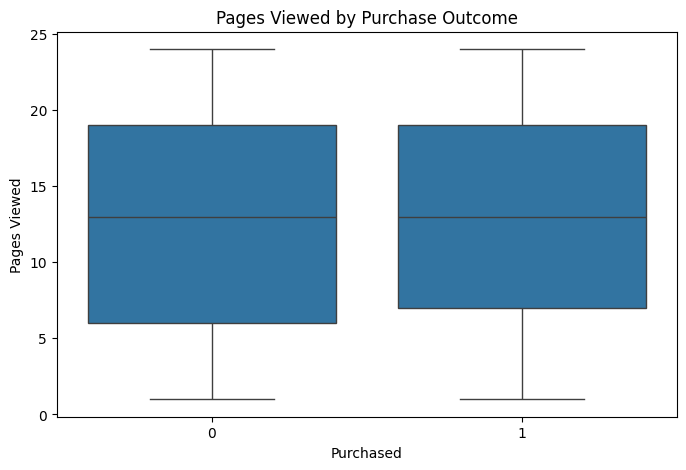

In [36]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean, x="purchased", y="pages_viewed")

plt.title("Pages Viewed by Purchase Outcome")
plt.xlabel("Purchased")
plt.ylabel("Pages Viewed")
plt.show()

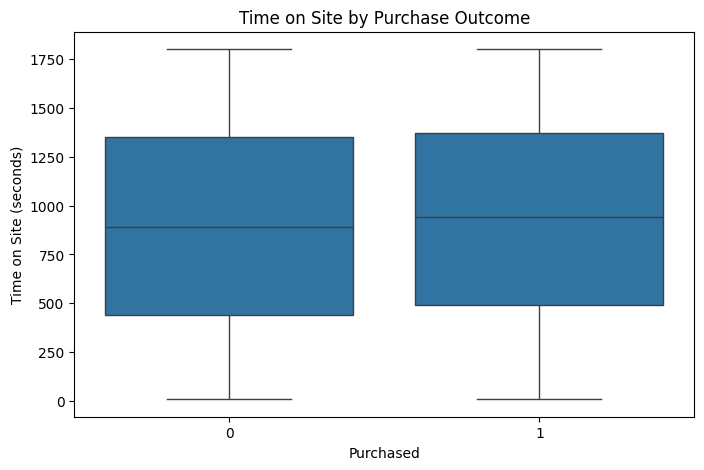

In [37]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df_clean, x="purchased", y="time_on_site_sec")

plt.title("Time on Site by Purchase Outcome")
plt.xlabel("Purchased")
plt.ylabel("Time on Site (seconds)")
plt.show()

In [38]:
cart_purchase = pd.crosstab(
    df_clean["added_to_cart"],
    df_clean["purchased"],
    normalize="index"
).mul(100).round(2)

display(cart_purchase)

purchased,0,1
added_to_cart,,
0,100.00,0.00
1,65.15,34.85


In [39]:
channel_purchase = (
    df_clean.groupby("marketing_channel")["purchased"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

display(channel_purchase.to_frame("Purchase Rate (%)"))

,Purchase Rate (%)
marketing_channel,
5,23.60
0,22.72
3,22.64
1,22.12
2,22.03
4,21.66


## 4.4 Correlation Analysis

In [40]:
correlation_data = df_clean.select_dtypes(include=np.number)
correlation_matrix = correlation_data.corr()
display(correlation_matrix)

,customer_id,session_id,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,discount_percent,discount_amount,revenue,pages_viewed,time_on_site_sec,added_to_cart,purchased,cart_abandoned,rating,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,revenue_normalized,location
customer_id,1.000000,0.004796,-0.010251,0.009025,0.002124,-0.003974,0.011538,0.010299,-0.007618,0.002666,0.000430,0.003435,-0.001252,0.016466,-0.001993,-0.000577,-0.001444,-0.001609,-0.004165,-0.001858,-0.001544,-0.006476,0.004441,-0.001714,0.001001,0.003435,-0.009357
session_id,0.004796,1.000000,-0.001398,0.008064,0.000849,-0.009039,0.007754,-0.005834,-0.001442,0.003892,-0.006998,-0.003413,0.002588,-0.004279,0.007132,0.002020,0.005208,0.001514,0.005759,-0.003584,-0.011094,-0.005680,-0.005894,-0.001154,-0.002760,-0.003413,-0.006367
device_type,-0.010251,-0.001398,1.000000,-0.001240,0.000973,-0.000351,-0.012320,-0.011983,-0.006948,0.004336,-0.007183,-0.003719,0.000959,-0.001495,0.001290,0.002772,-0.001093,0.002263,-0.000045,0.001842,0.002408,0.009200,0.008005,0.005381,-0.006860,-0.003719,0.008296
user_type,0.009025,0.008064,-0.001240,1.000000,0.011203,0.000063,0.016528,0.014297,-0.007573,-0.000794,0.004307,0.057986,0.015657,0.005379,-0.003693,0.084599,-0.075116,-0.014335,0.055411,0.069115,-0.003901,-0.011251,-0.005442,0.003657,0.006143,0.057986,-0.003863
marketing_channel,0.002124,0.000849,0.000973,0.011203,1.000000,0.003303,0.000869,0.007202,-0.007129,0.001042,0.001237,0.003856,0.001087,-0.001810,-0.008225,0.004506,-0.011786,0.005915,-0.000117,0.004561,-0.011475,0.003101,0.007113,-0.006762,-0.002898,0.003856,-0.004071
product_id,-0.003974,-0.009039,-0.000351,0.000063,0.003303,1.000000,0.005461,-0.008324,0.005505,0.007711,0.009544,0.006366,0.007768,0.003465,0.006451,0.011208,-0.003222,0.002035,0.010062,0.009334,-0.002265,0.001876,0.000196,0.000505,0.004698,0.006366,0.005037
product_category,0.011538,0.007754,-0.012320,0.016528,0.000869,0.005461,1.000000,0.148848,0.012725,-0.004647,0.053244,0.050829,-0.014582,-0.010112,0.010944,0.015382,-0.002395,-0.008168,0.005105,0.013873,-0.004731,-0.003205,0.003823,-0.001830,-0.003744,0.050829,-0.002542
unit_price,0.010299,-0.005834,-0.011983,0.014297,0.007202,-0.008324,0.148848,1.000000,0.005697,-0.002698,0.389413,0.248939,-0.004950,0.001682,0.002912,0.008561,-0.004415,-0.014720,0.007779,0.006575,-0.008714,-0.006047,0.005741,-0.009418,-0.003415,0.248939,-0.005232
quantity,-0.007618,-0.001442,-0.006948,-0.007573,-0.007129,0.005505,0.012725,0.005697,1.000000,-0.001838,0.288584,0.182036,-0.005273,0.005965,0.000836,0.004175,-0.002720,-0.003270,-0.006396,0.004247,0.015659,0.003767,0.000647,-0.008542,0.003732,0.182036,0.000205
discount_percent,0.002666,0.003892,0.004336,-0.000794,0.001042,0.007711,-0.004647,-0.002698,-0.001838,1.000000,0.671354,-0.043151,-0.003653,0.007165,0.007185,0.001322,0.005849,0.016686,0.000831,-0.002590,-0.009451,0.000682,0.004618,-0.005712,-0.010529,-0.043151,0.001374


###HeatMap

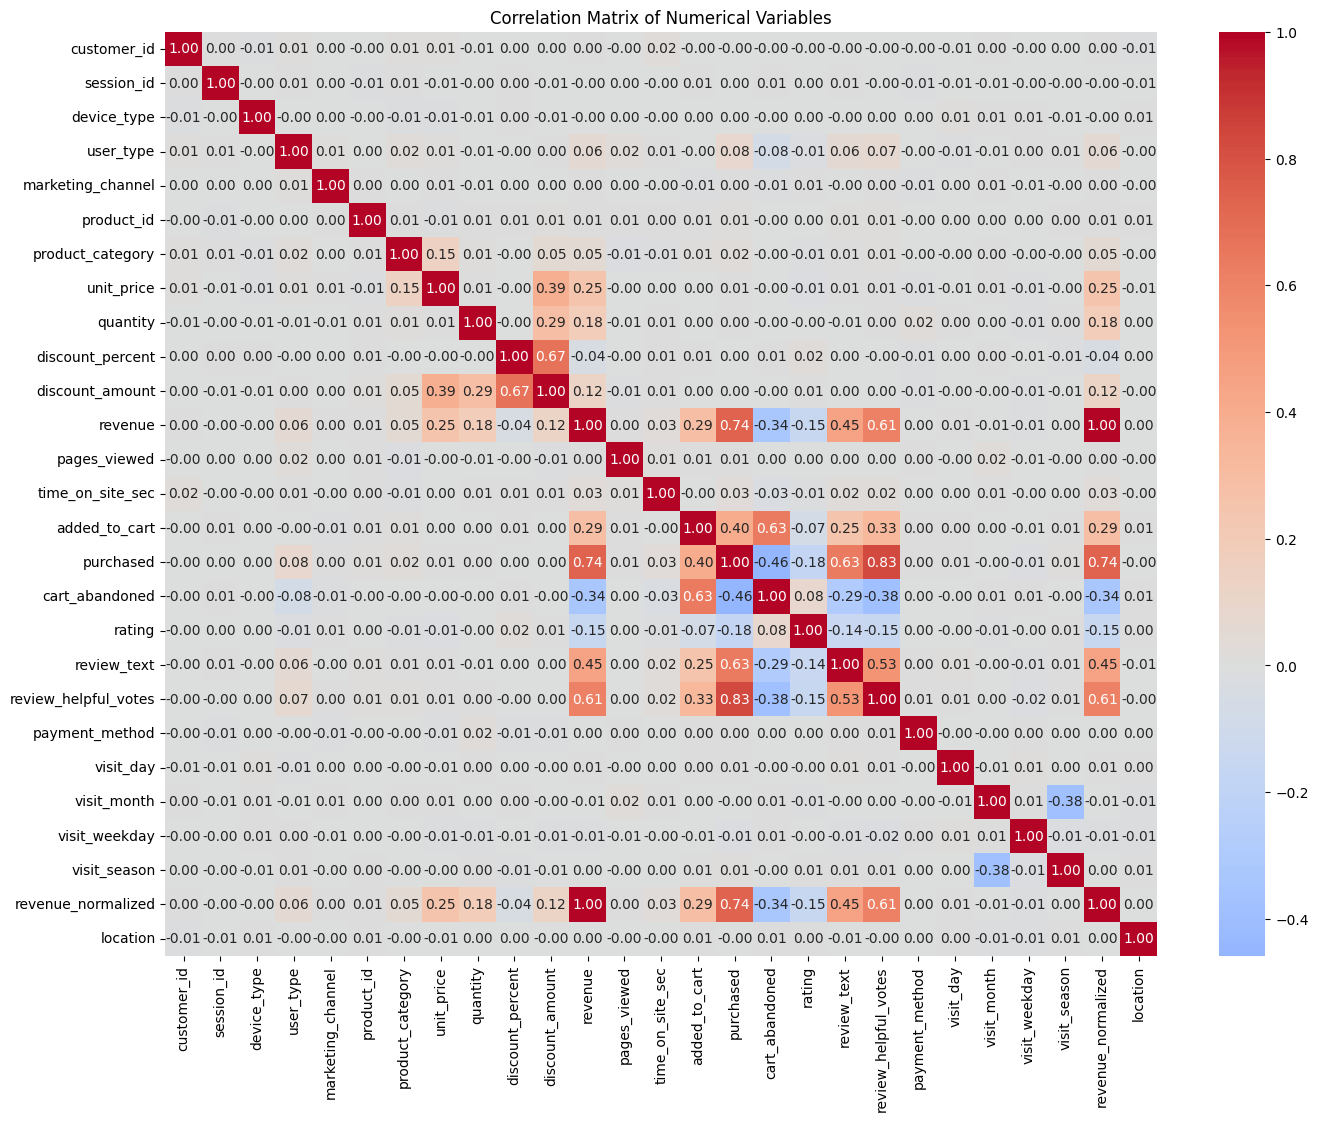

In [41]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")
plt.show()

In [42]:
target_correlation = (
    correlation_matrix["purchased"]
    .drop("purchased")
    .sort_values(key=abs, ascending=False)
)

display(
    target_correlation.to_frame("Correlation with Purchased")
)

,Correlation with Purchased
review_helpful_votes,0.831446
revenue_normalized,0.735319
revenue,0.735319
review_text,0.631109
cart_abandoned,-0.458077
added_to_cart,0.399604
rating,-0.178751
user_type,0.084599
time_on_site_sec,0.027427
product_category,0.015382


In [43]:
strong_relationships = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

strong_relationships = (
    strong_relationships.stack()
    .sort_values(key=abs, ascending=False)
)

display(strong_relationships.head(10).to_frame("Correlation"))

Correlation
revenue              revenue_normalized       1.000000
purchased            review_helpful_votes     0.831446
                     revenue_normalized       0.735319
revenue              purchased                0.735319
discount_percent     discount_amount          0.671354
added_to_cart        cart_abandoned           0.631806
purchased            review_text              0.631109
review_helpful_votes revenue_normalized       0.609816
revenue              review_helpful_votes     0.609816
review_text          review_helpful_votes     0.525478

## 4.5 Business Insights

In [44]:
purchase_summary = df_clean.groupby("purchased")[
    ["pages_viewed", "time_on_site_sec", "added_to_cart"]
].mean()

display(purchase_summary)

,pages_viewed,time_on_site_sec,added_to_cart
purchased,,,
0,12.512846,895.605809,0.541735
1,12.615207,929.691952,1.000000


In [45]:
user_purchase = (
    df_clean.groupby("user_type")["purchased"]
    .mean()
    .mul(100)
    .round(2)
)

display(user_purchase.to_frame("Purchase Rate (%)"))

,Purchase Rate (%)
user_type,
0,18.55
1,25.65


In [46]:
product_purchase = (
    df_clean.groupby("product_category")["purchased"]
    .mean()
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

display(product_purchase.to_frame("Purchase Rate (%)"))

,Purchase Rate (%)
product_category,
6,24.68
5,23.12
4,22.69
7,22.58
0,22.28
2,22.27
1,21.26
3,20.76


In [47]:
insight_groups = pd.DataFrame({
    "Marketing Channel": channel_purchase.head(3),
    "Product Category": product_purchase.head(3),
    "User Type": user_purchase.sort_values(ascending=False).head(3)
})

display(insight_groups)

,Marketing Channel,Product Category,User Type
0,22.72,NaN,18.55
1,NaN,NaN,25.65
3,22.64,NaN,NaN
4,NaN,22.69,NaN
5,23.60,23.12,NaN
6,NaN,24.68,NaN


### EDA Summary

In [48]:
print("EDA Summary")
print("=" * 50)

print(f"Highest marketing-channel purchase rate: {channel_purchase.index[0]}")
print(f"Highest product-category purchase rate: {product_purchase.index[0]}")
print(f"Highest user-type purchase rate: {user_purchase.index[0]}")

EDA Summary
Highest marketing-channel purchase rate: 5
Highest product-category purchase rate: 6
Highest user-type purchase rate: 0


# 5. Statistical Analysis

Statistical analysis is performed to quantitatively summarize customer and session behaviour in the e-commerce dataset.

Measures of central tendency and dispersion are used to understand the typical values and variability of important numerical variables.

The analysis also compares these measures across purchase outcomes to identify differences between purchasing and non-purchasing sessions.

## 5.1 Measures of Central Tendency and Dispersion

In [49]:
stats_columns = [
    "unit_price",
    "quantity",
    "pages_viewed",
    "time_on_site_sec",
    "rating"
]

statistics_summary = pd.DataFrame({
    "Mean": df_clean[stats_columns].mean(),
    "Median": df_clean[stats_columns].median(),
    "Std Dev": df_clean[stats_columns].std()
})

display(statistics_summary.round(2))

,Mean,Median,Std Dev
unit_price,782.32,691.72,476.61
quantity,2.49,2.00,1.11
pages_viewed,12.54,13.00,6.93
time_on_site_sec,903.26,903.00,518.68
rating,3.95,4.00,0.54


In [50]:
q1 = df_clean[stats_columns].quantile(0.25)
q3 = df_clean[stats_columns].quantile(0.75)

iqr_summary = pd.DataFrame({
    "Q1": q1,
    "Q3": q3,
    "IQR": q3 - q1
})

display(iqr_summary.round(2))

,Q1,Q3,IQR
unit_price,395.22,1096.84,701.62
quantity,1.00,3.00,2.00
pages_viewed,7.00,19.00,12.00
time_on_site_sec,453.00,1355.00,902.00
rating,4.00,4.00,0.00


In [51]:
purchase_statistics = df_clean.groupby("purchased")[stats_columns].agg(
    ["mean", "median", "std"]
)

display(purchase_statistics.round(2))

unit_price                 quantity              pages_viewed  \
                mean  median     std     mean median   std         mean   
purchased                                                                 
0             780.12  690.46  475.14     2.49    2.0  1.11        12.51   
1             789.90  694.44  481.63     2.50    2.0  1.11        12.62   

                       time_on_site_sec                rating               
          median   std             mean median     std   mean median   std  
purchased                                                                   
0           13.0  6.93           895.61  890.0  521.30   4.00    4.0  0.00  
1           13.0  6.92           929.69  942.5  508.67   3.77    4.0  1.12

In [52]:
purchase_comparison = df_clean.groupby("purchased")[
    ["pages_viewed", "time_on_site_sec", "quantity"]
].mean()

display(purchase_comparison.round(2))

,pages_viewed,time_on_site_sec,quantity
purchased,,,
0,12.51,895.61,2.49
1,12.62,929.69,2.50


## 5.2 Group Analysis

In [53]:
user_group = df_clean.groupby("user_type").agg(
    Sessions=("purchased", "size"),
    Purchases=("purchased", "sum"),
    Purchase_Rate=("purchased", "mean")
)

user_group["Purchase_Rate"] = user_group["Purchase_Rate"].mul(100).round(2)

display(user_group)

,Sessions,Purchases,Purchase_Rate
user_type,,,
0,11218,2081,18.55
1,13782,3535,25.65


In [54]:
channel_group = df_clean.groupby("marketing_channel").agg(
    Sessions=("purchased", "size"),
    Purchases=("purchased", "sum"),
    Purchase_Rate=("purchased", "mean")
)

channel_group["Purchase_Rate"] = channel_group["Purchase_Rate"].mul(100).round(2)

display(channel_group.sort_values("Purchase_Rate", ascending=False))

,Sessions,Purchases,Purchase_Rate
marketing_channel,,,
5,4263,1006,23.60
0,4041,918,22.72
3,4116,932,22.64
1,4190,927,22.12
2,4281,943,22.03
4,4109,890,21.66


In [55]:
product_group = df_clean.groupby("product_category").agg(
    Sessions=("purchased", "size"),
    Purchases=("purchased", "sum"),
    Purchase_Rate=("purchased", "mean")
)

product_group["Purchase_Rate"] = product_group["Purchase_Rate"].mul(100).round(2)

display(product_group.sort_values("Purchase_Rate", ascending=False))

,Sessions,Purchases,Purchase_Rate
product_category,,,
6,3112,768,24.68
5,3149,728,23.12
4,3204,727,22.69
7,3073,694,22.58
0,3142,700,22.28
2,3237,721,22.27
1,3043,647,21.26
3,3040,631,20.76


In [56]:
behaviour_group = df_clean.groupby("purchased").agg(
    Avg_Pages=("pages_viewed", "mean"),
    Avg_Time=("time_on_site_sec", "mean"),
    Avg_Quantity=("quantity", "mean")
)

display(behaviour_group.round(2))

,Avg_Pages,Avg_Time,Avg_Quantity
purchased,,,
0,12.51,895.61,2.49
1,12.62,929.69,2.50


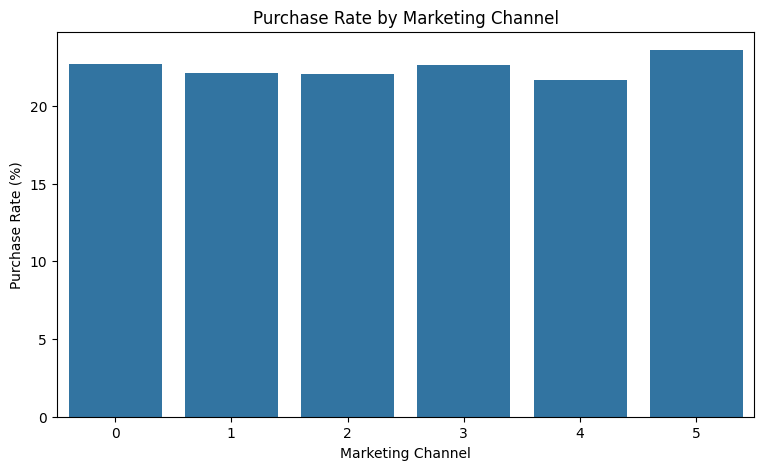

In [57]:
# Group Analysis Visualization

plt.figure(figsize=(9, 5))

sns.barplot(
    data=channel_group.reset_index(),
    x="marketing_channel",
    y="Purchase_Rate"
)

plt.title("Purchase Rate by Marketing Channel")
plt.xlabel("Marketing Channel")
plt.ylabel("Purchase Rate (%)")
plt.show()

## 5.3 Correlation-Based Analysis

In [58]:
purchase_corr = (
    df_clean.select_dtypes(include=np.number)
    .corr()["purchased"]
    .drop("purchased")
    .sort_values(key=abs, ascending=False)
)

display(purchase_corr.to_frame("Correlation"))

,Correlation
review_helpful_votes,0.831446
revenue_normalized,0.735319
revenue,0.735319
review_text,0.631109
cart_abandoned,-0.458077
added_to_cart,0.399604
rating,-0.178751
user_type,0.084599
time_on_site_sec,0.027427
product_category,0.015382


In [59]:
positive_corr = purchase_corr.sort_values(ascending=False).head(5)
negative_corr = purchase_corr.sort_values().head(5)

print("Strongest Positive Relationships")
display(positive_corr.to_frame("Correlation"))

print("Strongest Negative Relationships")
display(negative_corr.to_frame("Correlation"))

Strongest Positive Relationships


,Correlation
review_helpful_votes,0.831446
revenue_normalized,0.735319
revenue,0.735319
review_text,0.631109
added_to_cart,0.399604


Strongest Negative Relationships


,Correlation
cart_abandoned,-0.458077
rating,-0.178751
visit_weekday,-0.014006
visit_month,-0.004049
location,-0.001429


In [60]:
statistical_summary = statistics_summary.copy()
statistical_summary["IQR"] = iqr_summary["IQR"]

display(statistical_summary.round(2))

,Mean,Median,Std Dev,IQR
unit_price,782.32,691.72,476.61,701.62
quantity,2.49,2.00,1.11,2.00
pages_viewed,12.54,13.00,6.93,12.00
time_on_site_sec,903.26,903.00,518.68,902.00
rating,3.95,4.00,0.54,0.00


In [61]:
# Phase 5 Checking Summaery

print("=" * 60)
print("PHASE 4 — STATISTICAL ANALYSIS")
print("=" * 60)

print("Mean, Median, Standard Deviation : Completed")
print("IQR                              : Completed")
print("Group Analysis                   : Completed")
print("Correlation Analysis             : Completed")

PHASE 4 — STATISTICAL ANALYSIS
Mean, Median, Standard Deviation : Completed
IQR                              : Completed
Group Analysis                   : Completed
Correlation Analysis             : Completed


# 6. Feature Engineering

Feature engineering prepares the cleaned dataset for machine learning by selecting relevant predictors and identifying variables that may introduce data leakage.

Features are selected based on their availability before or during the customer purchase decision.

Variables that directly represent the outcome or are generated after the outcome are excluded from the modelling dataset.

## 6.1 Identify Potential Leakage

In [62]:
target_column = "purchased"

potential_leakage = [
    "purchased",
    "revenue",
    "revenue_normalized",
    "cart_abandoned"
]

leakage_check = df_clean[potential_leakage].describe().T

display(leakage_check)

,count,mean,std,min,25%,50%,75%,max
purchased,25000.0,0.224640,0.417353,0.0,0.0,0.0,0.0,1.00
revenue,25000.0,404.646762,1022.391774,0.0,0.0,0.0,0.0,7889.36
revenue_normalized,25000.0,0.051290,0.129591,0.0,0.0,0.0,0.0,1.00
cart_abandoned,25000.0,0.420040,0.493575,0.0,0.0,0.0,1.0,1.00


In [63]:
leakage_relationships = df_clean.groupby("purchased")[
    ["revenue", "revenue_normalized", "cart_abandoned"]
].mean()

display(leakage_relationships)

,revenue,revenue_normalized,cart_abandoned
purchased,,,
0,0.000000,0.000000,0.541735
1,1801.312155,0.228322,0.000000


In [64]:
excluded_columns = [
    "purchased",
    "revenue",
    "revenue_normalized",
    "cart_abandoned"
]

feature_columns = [
    col for col in df_clean.columns
    if col not in excluded_columns
]

print("Total features:", len(feature_columns))
print(feature_columns)

Total features: 25
['customer_id', 'session_id', 'visit_date', 'device_type', 'user_type', 'marketing_channel', 'product_id', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'rating', 'review_text', 'review_helpful_votes', 'payment_method', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'session_duration_bucket', 'location']


In [65]:
X = df_clean[feature_columns].copy()
y = df_clean[target_column].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (25000, 25)
y shape: (25000,)


In [66]:
# Final target ..
print("Target variable:", target_column)
print("Target classes:", sorted(y.unique()))
print("Target distribution:")

display(
    y.value_counts()
    .sort_index()
    .to_frame("Count")
)

Target variable: purchased
Target classes: [np.int64(0), np.int64(1)]
Target distribution:


,Count
purchased,
0,19384
1,5616


## 6.2 Feature Type Analysis

In [67]:
feature_dtypes = X.dtypes.to_frame("Data Type")

display(feature_dtypes)

,Data Type
customer_id,int64
session_id,int64
visit_date,object
device_type,int64
user_type,int64
marketing_channel,int64
product_id,int64
product_category,int64
unit_price,float64
quantity,int64


In [68]:
# Identify the Numerical Data
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Numerical features:", len(numeric_features))
print(numeric_features)

Numerical features: 23
['customer_id', 'session_id', 'device_type', 'user_type', 'marketing_channel', 'product_id', 'product_category', 'unit_price', 'quantity', 'discount_percent', 'discount_amount', 'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'rating', 'review_text', 'review_helpful_votes', 'payment_method', 'visit_day', 'visit_month', 'visit_weekday', 'visit_season', 'location']


In [69]:
# Identify the categorical data
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Categorical features:", len(categorical_features))
print(categorical_features)

Categorical features: 2
['visit_date', 'session_duration_bucket']


In [70]:
print("visit_date dtype:", X["visit_date"].dtype)
print("Sample visit dates:")

display(X["visit_date"].head())

visit_date dtype: object
Sample visit dates:


,visit_date
0,28-11-2024
1,25-09-2024
2,31-05-2024
3,30-01-2024
4,25-02-2024


In [71]:
# Cobvert date and extract the feature

X["visit_date"] = pd.to_datetime(
    X["visit_date"],
    format="%d-%m-%Y"
)

X["visit_year"] = X["visit_date"].dt.year
X["visit_day_of_year"] = X["visit_date"].dt.dayofyear

In [72]:
X["visit_date"] = pd.to_datetime(
    X["visit_date"],
    format="%d-%m-%Y"
)

X["visit_year"] = X["visit_date"].dt.year
X["visit_day_of_year"] = X["visit_date"].dt.dayofyear

In [73]:
# Remove Raw Dates

X = X.drop(columns=["visit_date"])

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

print("Final numerical features:", len(numeric_features))
print("Final categorical features:", len(categorical_features))

Final numerical features: 25
Final categorical features: 1


In [74]:
print("Final X shape:", X.shape)
print("Target y shape:", y.shape)

print("\nRemaining missing values:", X.isna().sum().sum())
print("Target missing values:", y.isna().sum())

Final X shape: (25000, 26)
Target y shape: (25000,)

Remaining missing values: 0
Target missing values: 0


# 7. Machine Learning Methodology

The prepared dataset is divided into training and testing subsets to evaluate model performance on unseen data.

A preprocessing pipeline is used to handle numerical and categorical features consistently.

Three classification algorithms are trained:

- Logistic Regression
- Decision Tree
- Random Forest


# Train - Test Split

In [75]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 20000
Testing samples : 5000


In [76]:
# verify the target distribution
print("Training target distribution:")
display(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True).round(3))

Training target distribution:


,proportion
purchased,
0,0.775
1,0.225



Testing target distribution:


,proportion
purchased,
0,0.775
1,0.225


## 7.2 Preprocessing Pipeline

In [77]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [78]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features)) # --> Create the processor

Numerical features: 25
Categorical features: 1


In [79]:
print("Preprocessing transformers:")

for name, transformer, columns in preprocessor.transformers:
    print(f"{name}: {len(columns)} features")

Preprocessing transformers:
num: 25 features
cat: 1 features


## 7.3 Logistic Regression

Logistic Regression is used as a baseline classification model.

In [80]:
from sklearn.linear_model import LogisticRegression

logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [81]:
logistic_model.fit(X_train, y_train)
logistic_predictions = logistic_model.predict(X_test)
print("Logistic Regression training completed.")

Logistic Regression training completed.


## 7.4 Decision Tree

A Decision Tree classifier models relationships between features through a sequence of decision rules.

In [82]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=8
    ))
])

In [83]:
decision_tree_model.fit(X_train, y_train)
decision_tree_predictions = decision_tree_model.predict(X_test)
print("Decision Tree training completed.")

Decision Tree training completed.


## 7.5 Random Forest

In [84]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

In [85]:
random_forest_model.fit(X_train, y_train)
random_forest_predictions = random_forest_model.predict(X_test)
print("Random Forest training completed.")

Random Forest training completed.


# 8. Model Evaluation

The trained classification models are evaluated on the unseen test dataset.

In [86]:
model_predictions = {
    "Logistic Regression": logistic_model.predict(X_test),
    "Decision Tree": decision_tree_model.predict(X_test),
    "Random Forest": random_forest_model.predict(X_test)
}

print("Predictions generated for all models.")

Predictions generated for all models.


In [87]:
model_probabilities = {
    "Logistic Regression": logistic_model.predict_proba(X_test)[:, 1],
    "Decision Tree": decision_tree_model.predict_proba(X_test)[:, 1],
    "Random Forest": random_forest_model.predict_proba(X_test)[:, 1]
}

print("Prediction probabilities generated.")

Prediction probabilities generated.


## 8.2 Classification Metrics

The models are compared using four standard classification metrics.

- Accuracy measures the overall proportion of correct predictions.
- Precision measures the proportion of predicted purchases that were actually purchases.
- Recall measures the proportion of actual purchases correctly identified.
- F1-score provides a balance between precision and recall.

In [88]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [89]:
# Calculate Metrics
evaluation_results = []

for model_name, predictions in model_predictions.items():
    probabilities = model_probabilities[model_name]

    evaluation_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

metrics_df = pd.DataFrame(evaluation_results)

display(metrics_df.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9932,1.0,0.9697,0.9846,0.997
1,Decision Tree,1.0000,1.0,1.0000,1.0000,1.000
2,Random Forest,1.0000,1.0,1.0000,1.0000,1.000


In [90]:
# Percentage View
metrics_percentage = metrics_df.copy()

metric_columns = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

metrics_percentage[metric_columns] = (
    metrics_percentage[metric_columns] * 100
).round(2)

display(metrics_percentage)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,99.32,100.0,96.97,98.46,99.7
1,Decision Tree,100.00,100.0,100.00,100.00,100.0
2,Random Forest,100.00,100.0,100.00,100.00,100.0


## 8.3 Confusion Matrix

In [91]:
from sklearn.metrics import confusion_matrix

confusion_matrices = {}

for model_name, predictions in model_predictions.items():
    confusion_matrices[model_name] = confusion_matrix(
        y_test,
        predictions
    )

    print(f"\n{model_name}")
    display(confusion_matrices[model_name])


Logistic Regression


array([[3877,    0],
       [  34, 1089]])


Decision Tree


array([[3877,    0],
       [   0, 1123]])


Random Forest


array([[3877,    0],
       [   0, 1123]])

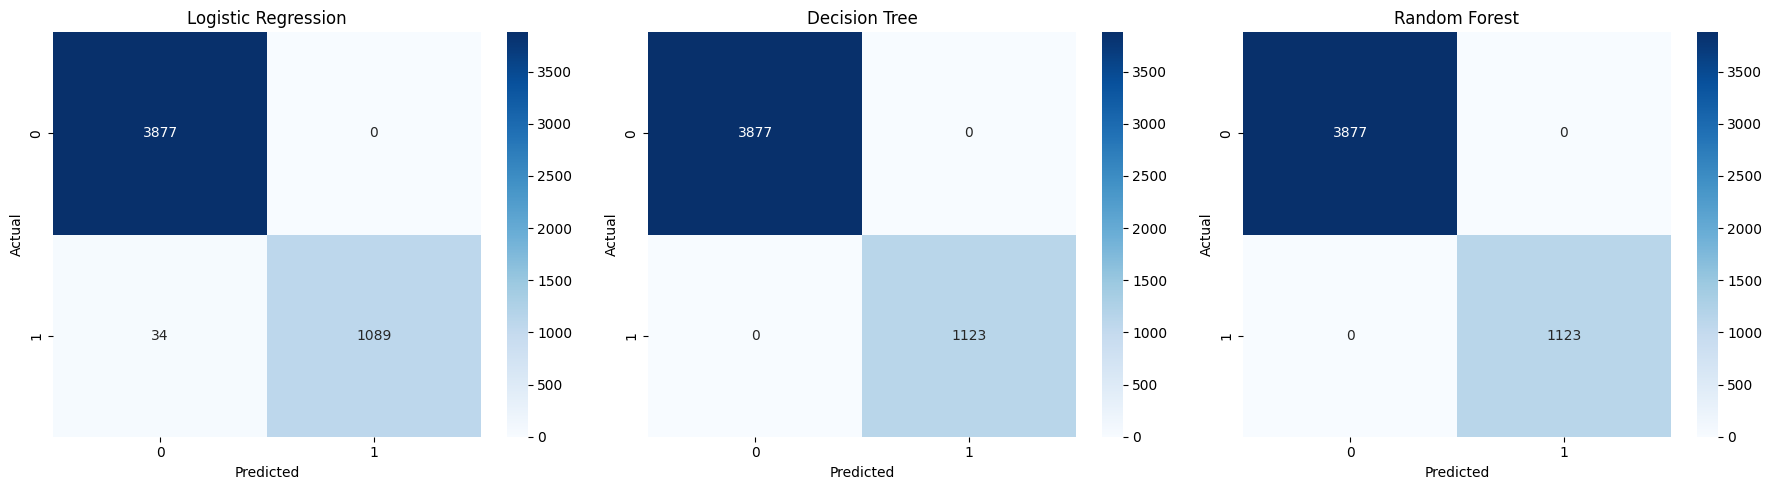

In [92]:
# Visualize Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, matrix) in zip(
    axes,
    confusion_matrices.items()
):
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 8.4 ROC Curve and ROC-AUC

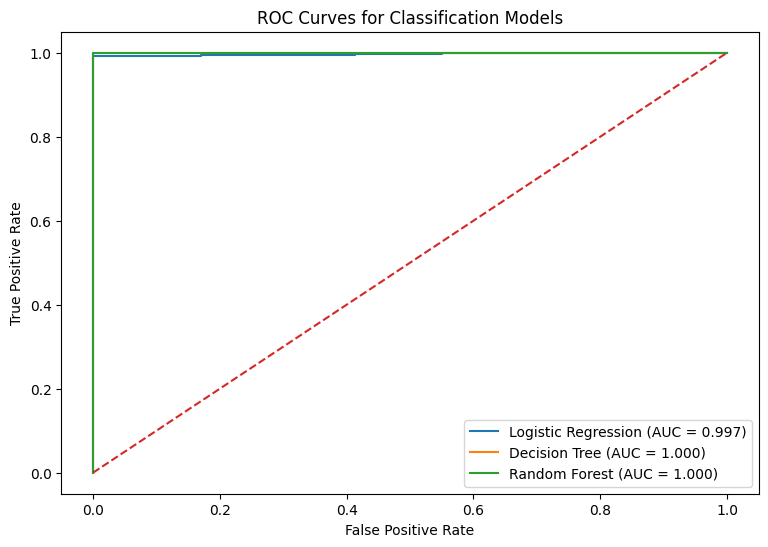

In [93]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(9, 6))

for model_name, probabilities in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probabilities)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC = {roc_auc_score(y_test, probabilities):.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Classification Models")
plt.legend()
plt.show()

## 8.5 Model Comparison

In [94]:
comparison = metrics_df.set_index("Model").sort_values(
    "F1-Score",
    ascending=False
)

display(comparison.round(4))

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Decision Tree,1.0000,1.0,1.0000,1.0000,1.000
Random Forest,1.0000,1.0,1.0000,1.0000,1.000
Logistic Regression,0.9932,1.0,0.9697,0.9846,0.997


## Summary

In [95]:
print("=" * 60)
print("PHASE 7 — MODEL EVALUATION")
print("=" * 60)

print("Accuracy       : Calculated")
print("Precision      : Calculated")
print("Recall         : Calculated")
print("F1-Score       : Calculated")
print("ROC-AUC        : Calculated")
print("Confusion Matrix: Generated")
print("ROC Curves     : Generated")

PHASE 7 — MODEL EVALUATION
Accuracy       : Calculated
Precision      : Calculated
Recall         : Calculated
F1-Score       : Calculated
ROC-AUC        : Calculated
Confusion Matrix: Generated
ROC Curves     : Generated


# 9. Final Model Pipeline

The final machine learning pipeline combines feature preprocessing and the selected classification model into a single reusable object.

## Model Selection

In [96]:
best_model_name = metrics_df.loc[
    metrics_df["F1-Score"].idxmax(),
    "Model"
]

print("Selected model:", best_model_name)

Selected model: Decision Tree


In [97]:
trained_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": decision_tree_model,
    "Random Forest": random_forest_model
}

selected_model = trained_models[best_model_name]

print("Final model pipeline selected successfully.")

Final model pipeline selected successfully.


In [98]:
selected_metrics = metrics_df[
    metrics_df["Model"] == best_model_name
]

display(selected_metrics.round(4))

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Decision Tree,1.0,1.0,1.0,1.0,1.0


## 9.2 Create Final Pipeline

In [99]:
final_pipeline = selected_model
print(final_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['customer_id', 'session_id',
                                                   'device_type', 'user_type',
                                                   'marketing_channel',
                                                   'product_id',
                                                   'product_category',
                                                   'unit_price', 'quantity',
                                                   'discount_percent',
                                                   'discount_amount',
                                                   'pages_viewed',
                                                   'time_on_site_sec',
                                                   'added_to_cart', 'rating',
                                                   'review_text',
                         

In [100]:
final_pipeline.fit(X_train, y_train)
print("Final pipeline trained successfully.")

Final pipeline trained successfully.


## 9.3 Save the Final Model

In [101]:
import joblib

model_file = "P10_purchase_intent_model.joblib"

joblib.dump(final_pipeline, model_file)

print("Model saved successfully.")
print("File:", model_file)

Model saved successfully.
File: P10_purchase_intent_model.joblib


In [102]:
import os

print("File exists:", os.path.exists(model_file))
print("File size:", f"{os.path.getsize(model_file) / 1024:.2f} KB")

File exists: True
File size: 6.04 KB


## Download the model file,..


In [103]:
from google.colab import files
files.download(model_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9.4 Test the Saved Model

In [104]:
loaded_model = joblib.load(model_file)
saved_predictions = loaded_model.predict(X_test)
print("Saved model loaded successfully.")
print("Predictions generated:", len(saved_predictions))

Saved model loaded successfully.
Predictions generated: 5000


In [105]:
saved_accuracy = accuracy_score(
    y_test,
    saved_predictions
)

print(f"Loaded model accuracy: {saved_accuracy:.4f}")

Loaded model accuracy: 1.0000


Model accuracy

In [106]:
from sklearn.metrics import classification_report, accuracy_score

# Generate predictions using the loaded model
test_predictions = loaded_model.predict(X_test)
accuracy = accuracy_score(y_test, test_predictions)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, test_predictions))

Model Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3877
           1       1.00      1.00      1.00      1123

    accuracy                           1.00      5000
   macro avg       1.00      1.00      1.00      5000
weighted avg       1.00      1.00      1.00      5000



In [107]:
print("=" * 60)
print("PHASE 8 — MODEL PACKAGING")
print("=" * 60)

print("Selected Model :", best_model_name)
print("Model File     :", model_file)
print("Model Verified : Yes")

PHASE 8 — MODEL PACKAGING
Selected Model : Decision Tree
Model File     : P10_purchase_intent_model.joblib
Model Verified : Yes


# Final Project Summary

The project developed a machine learning pipeline for predicting customer purchase intent from online shopping session behaviour.

The workflow included data understanding, cleaning, exploratory data analysis, statistical analysis, feature engineering, classification model training, model evaluation, and model packaging.

The final trained pipeline was saved as `P10_purchase_intent_model.joblib` for integration with the FastAPI backend and React frontend.

                 COLAB
                   │
                   │
       P10_purchase_intent_model.joblib
                   │
                   │ copied
                   ▼
              ┌─────────┐
              │  MODEL  │
              └────┬────┘
                   │
                   ▼
              ┌─────────┐
              │ FastAPI │
              └────┬────┘
                   │
                 /predict
                   │
                   ▼
              ┌─────────┐
              │ React   │
              │Frontend │
              └─────────┘